# Transfer Learning for 3D-Printed Image Classification

## Dataset Preparation and Shared Setup

In this section, We load and prepare the dataset for both deep learning models. We select 1,500 randomly chosen 256X256 images from each class, split the data into training, validation, and test sets, and save the images in the required folder structure.

In [4]:
import os, shutil, gc, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ============================================================
# CONFIGURATION
# ============================================================
IMG_SIZE=(256,256); BATCH_SIZE=16; SEED=42; PER_CLASS=1500
np.random.seed(SEED); tf.random.set_seed(SEED); rng=np.random.default_rng(SEED)

# ============================================================
# LOAD DATASET
# ============================================================
dataset=load_dataset("cmudrc/3d-printed-or-not")["train"]
labels_all=np.array(dataset["label"]); classes=np.unique(labels_all)
print("Full dataset:",len(dataset),"Labels:",np.bincount(labels_all))

# ============================================================
# FIND 256x256 IMAGES + RANDOMLY SAMPLE PER CLASS
# ============================================================
eligible={int(c):[] for c in classes}
for i,ex in enumerate(dataset):
    if ex["image"].size==(256,256): eligible[int(labels_all[i])].append(i)
print("Eligible 256x256 per class:",{c:len(v) for c,v in eligible.items()})

sel=[]
for c in classes:
    pool=np.array(eligible[int(c)]); take=min(PER_CLASS,len(pool))
    if take<PER_CLASS:
        print(f"WARNING: class {c} has only {take} eligible images, wanted {PER_CLASS}")
    sel.append(rng.choice(pool,size=take,replace=False))

sel_idx=np.sort(np.concatenate(sel)); labels=labels_all[sel_idx]; n=len(sel_idx)
print("Selected:",n,"Labels:",np.bincount(labels))

# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================
idx=np.arange(n)
train_idx,tmp_idx=train_test_split(idx,test_size=.2,stratify=labels,random_state=SEED)
val_idx,test_idx=train_test_split(tmp_idx,test_size=.5,stratify=labels[tmp_idx],random_state=SEED)

# ============================================================
# SAVE IMAGES TO TRAIN / VAL / TEST FOLDERS
# ============================================================
BASE=Path("data")
if BASE.exists(): shutil.rmtree(BASE)

split_of=np.empty(n,dtype=object)
split_of[train_idx]="train"; split_of[val_idx]="val"; split_of[test_idx]="test"

for s in ("train","val","test"):
    for c in classes: (BASE/s/f"class_{c}").mkdir(parents=True,exist_ok=True)

subset=dataset.select(sel_idx)
for j,ex in enumerate(subset):
    ex["image"].convert("RGB").save(BASE/split_of[j]/f"class_{labels[j]}"/f"{j:06d}.png")

del dataset,subset,eligible
gc.collect()

for s in ("train","val","test"):
    print(s,{d.name:len(list(d.glob("*.png"))) for d in sorted((BASE/s).iterdir())})

# ============================================================
# SHARED CLASS WEIGHTS
# ============================================================
y_train=labels[train_idx]
cw=compute_class_weight("balanced",classes=np.unique(y_train),y=y_train)
class_weights=dict(zip(np.unique(y_train),cw))
print("Class weights:",class_weights)

# ============================================================
# CLASS LABELS
# ============================================================
CLASS_LABELS=[f"class_{c}" for c in classes]
REAL_CLASS_LABELS = ["Not 3D Printed", "3D Printed"]

README.md:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

data/train-00000-of-00002-b2fb6cb9bbd227(…): reconstructing file:   0%|          |  0.00B /  243MB            

data/train-00000-of-00002-b2fb6cb9bbd227(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-fccaec415d2d33(…): reconstructing file:   0%|          |  0.00B /  254MB            

data/train-00001-of-00002-fccaec415d2d33(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/51520 [00:00<?, ? examples/s]

Full dataset: 51520 Labels: [25760 25760]
Eligible 256x256 per class: {0: 25728, 1: 25760}
Selected: 3000 Labels: [1500 1500]
train {'class_0': 1200, 'class_1': 1200}
val {'class_0': 150, 'class_1': 150}
test {'class_0': 150, 'class_1': 150}
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


## Images from the dataset

A selection of images from the dataset is presented below to illustrate the visual characteristics of the two classes.

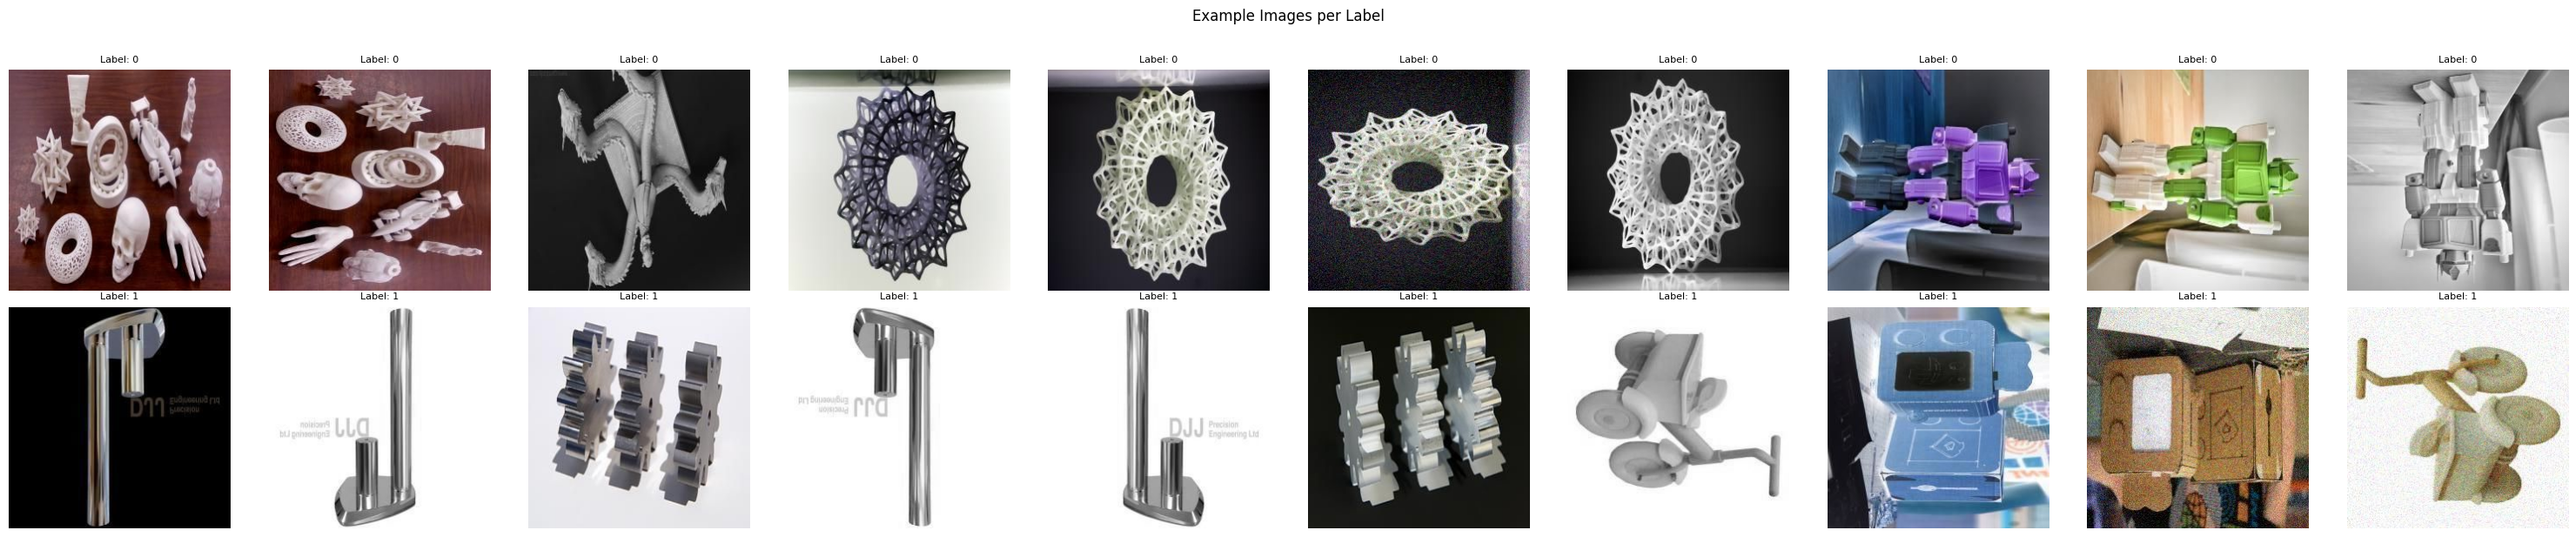

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Ensure BASE is defined (from previous cells)
# BASE = Path("data")

examples_per_class = 10
class_examples = {c: [] for c in classes}
class_counts = {c: 0 for c in classes}

# Iterate through the labels and collect image paths
# The original index j from `subset` (which corresponds to `labels` and `split_of` indices)
# is used in the filename f"{j:06d}.png"
for i in range(len(labels)):
    current_label = labels[i]
    if class_counts[current_label] < examples_per_class:
        image_path = BASE / split_of[i] / f"class_{current_label}" / f"{i:06d}.png"
        if image_path.exists():
            class_examples[current_label].append(image_path)
            class_counts[current_label] += 1

    # Break if we have enough examples for all classes
    if all(count == examples_per_class for count in class_counts.values()):
        break

# Display the images
fig, axes = plt.subplots(len(classes), examples_per_class, figsize=(examples_per_class * 3, len(classes) * 3)) # Increased figsize multipliers to make images bigger
fig.suptitle("Example Images per Label", y=1.02)

for r, class_id in enumerate(classes):
    for c, img_path in enumerate(class_examples[class_id]):
        img = Image.open(img_path)
        ax = axes[r, c] if len(classes) > 1 else axes[c] # Handle single class case
        ax.imshow(img)
        ax.set_title(f"Label: {CLASS_LABELS[class_id].split('_')[1]}", fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

## VGG16 Model

In this section, We train a VGG16-based binary classification model using the dataset prepared above. We first train the classification head while keeping the pretrained VGG16 base frozen, and then fine-tune the final four layers. No data augmentation is applied.


Found 2400 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
VGG class indices: {'class_0': 0, 'class_1': 1}
Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - accuracy: 0.7558 - loss: 0.7330 - val_accuracy: 0.8400 - val_loss: 0.3941
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.8733 - loss: 0.3297 - val_accuracy: 0.8733 - val_loss: 0.3367
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 144ms/step - accuracy: 0.9117 - loss: 0.2314 - val_accuracy: 0.8767 - val_loss: 0.3054

--- VGG16 Stage 2: Fine-tuning ---
Trainable parameters: 7211009
Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 169ms/step - accuracy: 0.9350 - loss: 0.1674 - val_accuracy: 0.8867 - val_loss: 0.2641
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 36s 156ms/step - accuracy: 0.9654 - loss: 0.0999 - val_accuracy: 0.8667 - val_loss: 0.3243
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 42s 162ms/step - accuracy: 0.9775 - loss: 0.0716 - val_accuracy: 0.8833 -

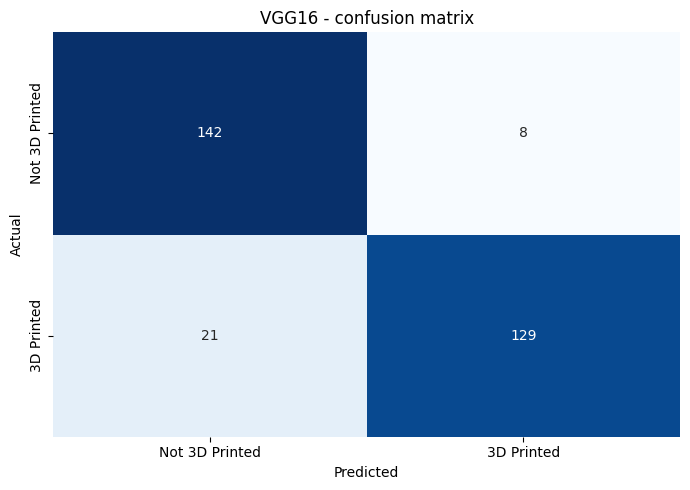


                precision    recall  f1-score   support

Not 3D Printed     0.8712    0.9467    0.9073       150
    3D Printed     0.9416    0.8600    0.8990       150

      accuracy                         0.9033       300
     macro avg     0.9064    0.9033    0.9032       300
  weighted avg     0.9064    0.9033    0.9032       300



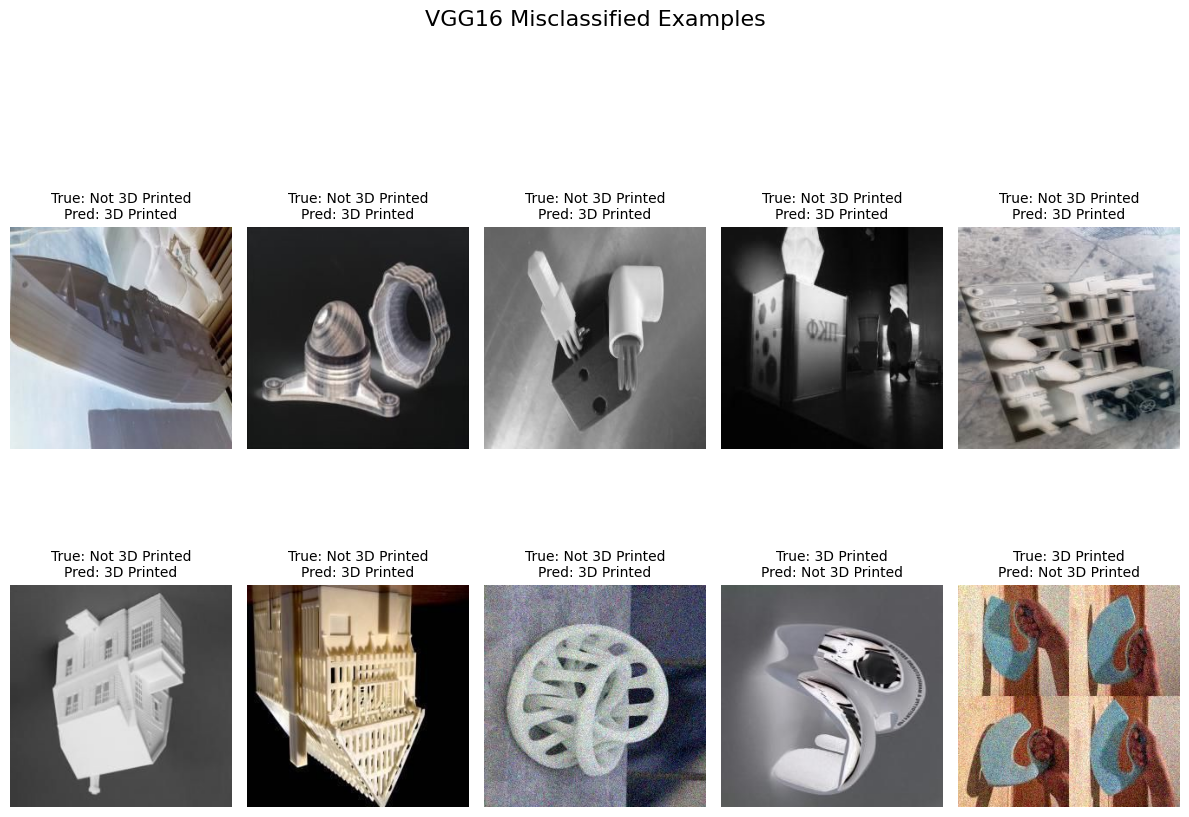

In [6]:
# ============================================================
# VGG16 IMPORTS & CONFIGURATION (Shared from K-1Le0DsEOG6)
# ============================================================
import os # Added for explicit path checking
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# Keras specific imports
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# Sklearn metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Configuration variables (copied from K-1Le0DsEOG6 for self-containment)
IMG_SIZE=(256,256); BATCH_SIZE=16; SEED=42; PER_CLASS=1500 # Ensure PER_CLASS is defined here for completeness
np.random.seed(SEED); tf.random.set_seed(SEED); # rng=np.random.default_rng(SEED) not needed here

# BASE Path definition
BASE=Path("data")

# Real class labels
REAL_CLASS_LABELS = ["Not 3D Printed", "3D Printed"]

# ============================================================
# VGG16 IMAGE GENERATORS
# ============================================================
vgg_datagen=ImageDataGenerator(preprocessing_function=preprocess_input)
vgg_train_generator=vgg_datagen.flow_from_directory(
    BASE/"train",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=True,seed=SEED
)
vgg_val_generator=vgg_datagen.flow_from_directory(
    BASE/"val",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=False
)
vgg_test_generator=vgg_datagen.flow_from_directory(
    BASE/"test",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=False
)
print("VGG class indices:",vgg_train_generator.class_indices)

# ============================================================
# BUILD VGG16 MODEL
# ============================================================
vgg_base=VGG16(weights="imagenet",include_top=False,input_shape=(256,256,3))
x=GlobalAveragePooling2D()(vgg_base.output)
x=Dense(256,activation="relu")(x)
x=Dropout(.5)(x)
output=Dense(1,activation="sigmoid")(x)
vgg_model=Model(vgg_base.input,output)

# ============================================================
# STAGE 1 — TRAIN CLASSIFICATION HEAD
# ============================================================
vgg_base.trainable=False
vgg_model.compile(Adam(1e-3),loss="binary_crossentropy",metrics=["accuracy"])
vgg_model.fit(
    vgg_train_generator,epochs=3,validation_data=vgg_val_generator,
    class_weight=class_weights,
    callbacks=[ModelCheckpoint("best_stage1_vgg.keras",monitor="val_accuracy",save_best_only=True)]
)

# ============================================================
# STAGE 2 — FINE-TUNE TOP 4 VGG16 LAYERS
# ============================================================
FINE_TUNE_LAYERS=4
print("\n--- VGG16 Stage 2: Fine-tuning ---")
vgg_model.load_weights("best_stage1_vgg.keras")
vgg_base.trainable=True
for layer in vgg_base.layers[:-FINE_TUNE_LAYERS]: layer.trainable=False

vgg_model.compile(Adam(1e-5),loss="binary_crossentropy",metrics=["accuracy"])
print("Trainable parameters:\n",sum(np.prod(w.shape) for w in vgg_model.trainable_weights))
vgg_model.fit(
    vgg_train_generator,epochs=3,validation_data=vgg_val_generator,
    class_weight=class_weights,
    callbacks=[ModelCheckpoint("best_stage2_vgg.keras",monitor="val_accuracy",save_best_only=True)]
)

# ============================================================
# FINAL EVALUATION
# ============================================================
vgg_test_generator.reset()
vgg_probs=vgg_model.predict(vgg_test_generator,verbose=0).ravel()
vgg_preds=(vgg_probs>.5).astype(int)
vgg_y_true=vgg_test_generator.classes

print("\n--- VGG16 Final Evaluation ---")
print(f"Accuracy:  {accuracy_score(vgg_y_true,vgg_preds):.4f}")
print(f"Precision: {precision_score(vgg_y_true,vgg_preds,zero_division=0):.4f}")
print(f"Recall:    {recall_score(vgg_y_true,vgg_preds,zero_division=0):.4f}")
print(f"F1:        {f1_score(vgg_y_true,vgg_preds,zero_division=0):.4f}")

vgg_model.save("final_vgg16_model.keras")
print("VGG16 model saved.")

# ============================================================
# CONFUSION MATRIX
# ============================================================
vgg_cm=confusion_matrix(vgg_y_true,vgg_preds)
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(vgg_cm,annot=True,fmt="d",cmap="Blues",cbar=False,
            xticklabels=REAL_CLASS_LABELS,yticklabels=REAL_CLASS_LABELS,ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("VGG16 - confusion matrix")
plt.tight_layout(); plt.show()

print("\n"+classification_report(
    vgg_y_true,vgg_preds,target_names=REAL_CLASS_LABELS,digits=4,zero_division=0
))

# ============================================================
# DISPLAY MISCLASSIFIED EXAMPLES
# ============================================================

misclassified_indices = np.where(vgg_y_true != vgg_preds)[0]

num_examples_to_show = 10
displayed_count = 0

plt.figure(figsize=(12, 10))
plt.suptitle("VGG16 Misclassified Examples", fontsize=16)

# Iterate through the indices of misclassified examples in the test generator
for i, gen_idx in enumerate(misclassified_indices):
    if displayed_count >= num_examples_to_show:
        break

    file_path_str = vgg_test_generator.filepaths[gen_idx]
    # Ensure absolute path for existence check and opening
    absolute_image_path = os.path.abspath(file_path_str)

    if os.path.exists(absolute_image_path):
        try:
            img = Image.open(absolute_image_path)

            # Get true and predicted labels directly from VGG results using gen_idx
            true_label_name = REAL_CLASS_LABELS[vgg_y_true[gen_idx]]
            predicted_label_name = REAL_CLASS_LABELS[vgg_preds[gen_idx]]

            ax = plt.subplot(2, 5, displayed_count + 1)
            ax.imshow(img)
            ax.set_title(f"True: {true_label_name}\nPred: {predicted_label_name}", fontsize=10)
            ax.axis('off')
            displayed_count += 1
        except Exception as e:
            print(f"Error opening image {absolute_image_path}: {e}")
    else:
        print(f"Warning: Image file not found at expected path: {absolute_image_path}")
        print(f"Filepath reported by generator: {file_path_str}")

if displayed_count == 0:
    print("No misclassified examples found or no images could be displayed.")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## ResNet50 Model

In this section, We train a ResNet50-based binary classification model using the same dataset and data split as VGG16. We first train the classification head while keeping the pretrained ResNet50 base frozen, and then fine-tune the final 20 layers. No data augmentation is applied.

Found 2400 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
ResNet50 class indices: {'class_0': 0, 'class_1': 1}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 139ms/step - accuracy: 0.7983 - loss: 0.4751 - val_accuracy: 0.8467 - val_loss: 0.3561
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.8896 - loss: 0.2673 - val_accuracy: 0.8833 - val_loss: 0.3299
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.9117 - loss: 0.2053 - val_accuracy: 0.8800 - val_loss: 0.3011

--- ResNet50 Stage 2: Fine-tuning ---
Trainable parameters: 9443841
Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.9337 - loss: 0.1716 - val_accuracy: 0.8867 - val_loss: 0.2788
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.9679 - loss: 0.1003 - val_accuracy: 0.8967 - val_loss: 0.2876
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - a

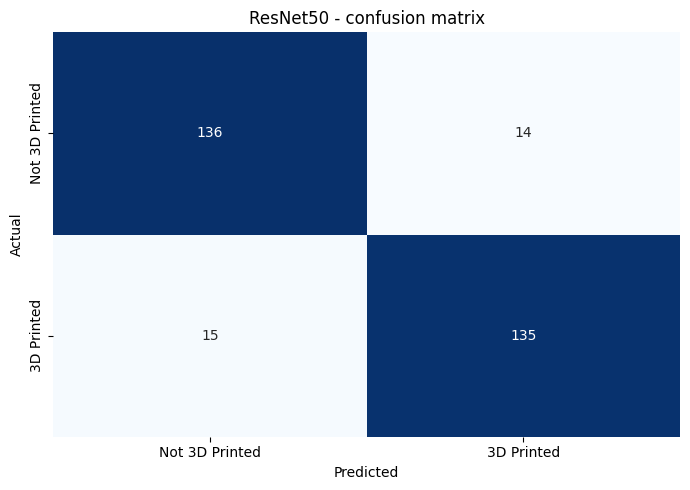


                precision    recall  f1-score   support

Not 3D Printed     0.9007    0.9067    0.9037       150
    3D Printed     0.9060    0.9000    0.9030       150

      accuracy                         0.9033       300
     macro avg     0.9034    0.9033    0.9033       300
  weighted avg     0.9034    0.9033    0.9033       300



In [ ]:
# ============================================================
# RESNET50 IMPORTS
# ============================================================
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# ============================================================
# RESNET50 IMAGE GENERATORS
# NO DATA AUGMENTATION
# ============================================================
resnet_datagen=ImageDataGenerator(preprocessing_function=preprocess_input)
resnet_train_generator=resnet_datagen.flow_from_directory(
    BASE/"train",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=True,seed=SEED
)
resnet_val_generator=resnet_datagen.flow_from_directory(
    BASE/"val",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=False
)
resnet_test_generator=resnet_datagen.flow_from_directory(
    BASE/"test",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=False
)
print("ResNet50 class indices:",resnet_train_generator.class_indices)

# ============================================================
# BUILD RESNET50 MODEL
# ============================================================
resnet_base=ResNet50(weights="imagenet",include_top=False,input_shape=(256,256,3))
x=GlobalAveragePooling2D()(resnet_base.output)
x=Dense(256,activation="relu")(x)
x=Dropout(.5)(x)
output=Dense(1,activation="sigmoid")(x)
resnet_model=Model(resnet_base.input,output)

# ============================================================
# STAGE 1 — TRAIN CLASSIFICATION HEAD
# ============================================================
resnet_base.trainable=False
resnet_model.compile(Adam(1e-3),loss="binary_crossentropy",metrics=["accuracy"])
resnet_model.fit(
    resnet_train_generator,epochs=3,validation_data=resnet_val_generator,
    class_weight=class_weights,
    callbacks=[ModelCheckpoint("best_stage1_resnet.keras",monitor="val_accuracy",save_best_only=True)]
)

# ============================================================
# STAGE 2 — FINE-TUNE TOP 20 RESNET50 LAYERS
# ============================================================
print("\n--- ResNet50 Stage 2: Fine-tuning ---")
resnet_model.load_weights("best_stage1_resnet.keras")
resnet_base.trainable=True
for layer in resnet_base.layers[:-20]: layer.trainable=False
for layer in resnet_base.layers:
    if isinstance(layer,BatchNormalization): layer.trainable=False

resnet_model.compile(Adam(1e-5),loss="binary_crossentropy",metrics=["accuracy"])
print("Trainable parameters:",sum(np.prod(w.shape) for w in resnet_model.trainable_weights))
resnet_model.fit(
    resnet_train_generator,epochs=3,validation_data=resnet_val_generator,
    class_weight=class_weights,
    callbacks=[ModelCheckpoint("best_stage2_resnet.keras",monitor="val_accuracy",save_best_only=True)]
)

# ============================================================
# FINAL EVALUATION
# ============================================================
resnet_test_generator.reset()
resnet_probs=resnet_model.predict(resnet_test_generator,verbose=0).ravel()
resnet_preds=(resnet_probs>.5).astype(int); resnet_y_true=resnet_test_generator.classes

print("\n--- ResNet50 Final Evaluation ---")
print(f"Accuracy:  {accuracy_score(resnet_y_true,resnet_preds):.4f}")
print(f"Precision: {precision_score(resnet_y_true,resnet_preds,zero_division=0):.4f}")
print(f"Recall:    {recall_score(resnet_y_true,resnet_preds,zero_division=0):.4f}")
print(f"F1:        {f1_score(resnet_y_true,resnet_preds,zero_division=0):.4f}")

resnet_model.save("final_resnet_model.keras")
print("ResNet50 model saved.")

# ============================================================
# CONFUSION MATRIX
# ============================================================
resnet_cm=confusion_matrix(resnet_y_true,resnet_preds)
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(resnet_cm,annot=True,fmt="d",cmap="Blues",cbar=False,
            xticklabels=REAL_CLASS_LABELS,yticklabels=REAL_CLASS_LABELS,ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("ResNet50 - confusion matrix")
plt.tight_layout(); plt.show()

print("\n"+classification_report(
    resnet_y_true,resnet_preds,target_names=REAL_CLASS_LABELS,digits=4,zero_division=0
))

## DenseNet121 Model

In this section, We train a DenseNet121-based binary classification model using the same dataset and data split as VGG16 and ResNet50. In Stage 1, all layers of the pretrained DenseNet121 base are frozen and only the classification head is trained. In Stage 2, the final 40 layers are fine-tuned while the remaining layers remain frozen. Batch normalization layers remain frozen during fine-tuning. No data augmentation is applied.

Found 2400 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
DenseNet121 class indices: {'class_0': 0, 'class_1': 1}
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 65s 252ms/step - accuracy: 0.7638 - loss: 0.5305 - val_accuracy: 0.8033 - val_loss: 0.4446
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.8525 - loss: 0.3489 - val_accuracy: 0.8300 - val_loss: 0.3783
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.8779 - loss: 0.2846 - val_accuracy: 0.8433 - val_loss: 0.3362

--- DenseNet121 Stage 2: Fine-tuning ---
Trainable parameters: 1077761
Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 62s 235ms/step - accuracy: 0.9162 - loss: 0.2267 - val_accuracy: 0.8533 - val_loss: 0.3242
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.9200 - loss: 0.2103 - val_accuracy: 0.8467 - val_loss: 0.3200
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/st

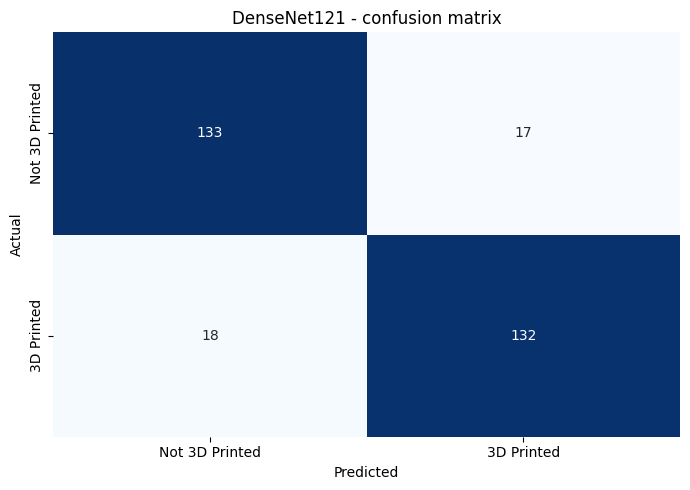


                precision    recall  f1-score   support

Not 3D Printed     0.8808    0.8867    0.8837       150
    3D Printed     0.8859    0.8800    0.8829       150

      accuracy                         0.8833       300
     macro avg     0.8834    0.8833    0.8833       300
  weighted avg     0.8834    0.8833    0.8833       300



In [ ]:
# ============================================================
# DENSENET121 IMPORTS
# ============================================================
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================================
# DENSENET121 IMAGE GENERATORS — NO DATA AUGMENTATION
# ============================================================
densenet_datagen=ImageDataGenerator(preprocessing_function=preprocess_input)
densenet_train_generator=densenet_datagen.flow_from_directory(
    BASE/"train",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=True,seed=SEED
)
densenet_val_generator=densenet_datagen.flow_from_directory(
    BASE/"val",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=False
)
densenet_test_generator=densenet_datagen.flow_from_directory(
    BASE/"test",target_size=IMG_SIZE,batch_size=BATCH_SIZE,
    class_mode="binary",shuffle=False
)
print("DenseNet121 class indices:",densenet_train_generator.class_indices)

# ============================================================
# BUILD DENSENET121 MODEL
# ============================================================
densenet_base=DenseNet121(weights="imagenet",include_top=False,input_shape=(256,256,3))
x=GlobalAveragePooling2D()(densenet_base.output)
x=Dense(256,activation="relu")(x)
x=Dropout(.5)(x)
output=Dense(1,activation="sigmoid")(x)
densenet_model=Model(densenet_base.input,output)

# ============================================================
# STAGE 1 — TRAIN CLASSIFICATION HEAD
# ============================================================
densenet_base.trainable=False
densenet_model.compile(Adam(1e-3),loss="binary_crossentropy",metrics=["accuracy"])
densenet_model.fit(
    densenet_train_generator,epochs=3,validation_data=densenet_val_generator,
    class_weight=class_weights,
    callbacks=[ModelCheckpoint("best_stage1_densenet.keras",monitor="val_accuracy",save_best_only=True)]
)

# ============================================================
# STAGE 2 — FINE-TUNE TOP 40 DENSENET121 LAYERS
# ============================================================
FINE_TUNE_LAYERS=40
print("\n--- DenseNet121 Stage 2: Fine-tuning ---")
densenet_model.load_weights("best_stage1_densenet.keras")
densenet_base.trainable=True

for layer in densenet_base.layers[:-FINE_TUNE_LAYERS]: layer.trainable=False
for layer in densenet_base.layers:
    if isinstance(layer,BatchNormalization): layer.trainable=False

densenet_model.compile(Adam(1e-5),loss="binary_crossentropy",metrics=["accuracy"])
print("Trainable parameters:",sum(np.prod(w.shape) for w in densenet_model.trainable_weights))
densenet_model.fit(
    densenet_train_generator,epochs=3,validation_data=densenet_val_generator,
    class_weight=class_weights,
    callbacks=[ModelCheckpoint("best_stage2_densenet.keras",monitor="val_accuracy",save_best_only=True)]
)

# ============================================================
# FINAL EVALUATION
# ============================================================
densenet_test_generator.reset()
densenet_probs=densenet_model.predict(densenet_test_generator,verbose=0).ravel()
densenet_preds=(densenet_probs>.5).astype(int)
densenet_y_true=densenet_test_generator.classes

print("\n--- DenseNet121 Final Evaluation ---")
print(f"Accuracy:  {accuracy_score(densenet_y_true,densenet_preds):.4f}")
print(f"Precision: {precision_score(densenet_y_true,densenet_preds,zero_division=0):.4f}")
print(f"Recall:    {recall_score(densenet_y_true,densenet_preds,zero_division=0):.4f}")
print(f"F1:        {f1_score(densenet_y_true,densenet_preds,zero_division=0):.4f}")

densenet_model.save("final_densenet121_model.keras")
print("DenseNet121 model saved.")

# ============================================================
# CONFUSION MATRIX + ADDITIONAL METRICS
# ============================================================
densenet_cm=confusion_matrix(densenet_y_true,densenet_preds)
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(densenet_cm,annot=True,fmt="d",cmap="Blues",cbar=False,
            xticklabels=REAL_CLASS_LABELS,yticklabels=REAL_CLASS_LABELS,ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("DenseNet121 - confusion matrix")
plt.tight_layout(); plt.show()

print("\n"+classification_report(
    densenet_y_true,densenet_preds,target_names=REAL_CLASS_LABELS,digits=4,zero_division=0
))

## Comparison

The following presents a comparison of VGG16, ResNet50, and DenseNet121 based on accuracy and F1-score. Accuracy represents the percentage of correctly classified images, while the F1-score is the harmonic mean of precision and recall. Higher values indicate better classification performance.

| Model       | Accuracy   | F1-Score   | Parameters   |
|:------------|:-----------|:-----------|:-------------|
| VGG16       | 0.916667   | 0.918567   | 14846273     |
| ResNet50    | 0.903333   | 0.90301    | 24112513     |
| DenseNet121 | 0.883333   | 0.882943   | 7300161      |


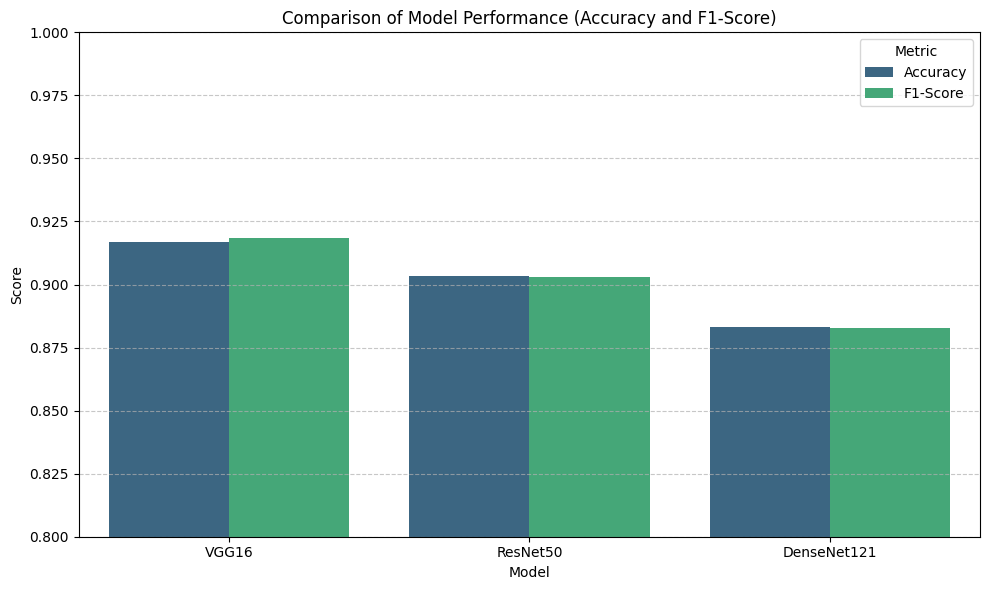

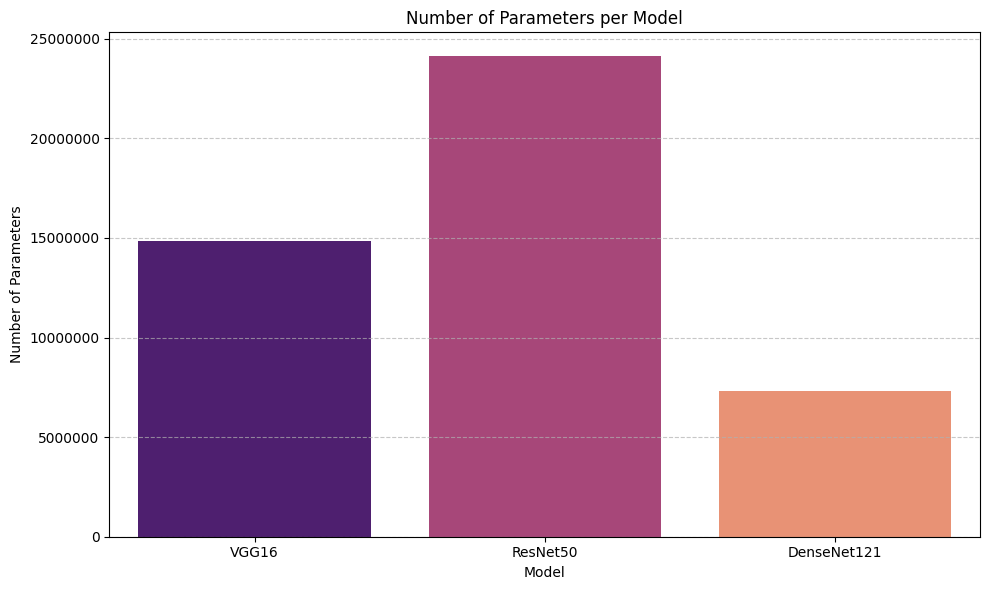

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics for VGG16
vgg_accuracy = accuracy_score(vgg_y_true, vgg_preds)
vgg_f1 = f1_score(vgg_y_true, vgg_preds, zero_division=0)
vgg_params = vgg_model.count_params()

# Calculate metrics for ResNet50
resnet_accuracy = accuracy_score(resnet_y_true, resnet_preds)
resnet_f1 = f1_score(resnet_y_true, resnet_preds, zero_division=0)
resnet_params = resnet_model.count_params()

# Calculate metrics for DenseNet121
densenet_accuracy = accuracy_score(densenet_y_true, densenet_preds)
densenet_f1 = f1_score(densenet_y_true, densenet_preds, zero_division=0)
densenet_params = densenet_model.count_params()

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['VGG16', 'ResNet50', 'DenseNet121'],
    'Accuracy': [vgg_accuracy, resnet_accuracy, densenet_accuracy],
    'F1-Score': [vgg_f1, resnet_f1, densenet_f1],
    'Parameters': [vgg_params, resnet_params, densenet_params]
})

print(comparison_df.to_markdown(index=False, numalign="left", stralign="left"))


# Melt the DataFrame to long format for easier plotting with seaborn
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot Accuracy and F1-Score
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=comparison_melted[comparison_melted['Metric'].isin(['Accuracy', 'F1-Score'])], palette='viridis')
plt.title('Comparison of Model Performance (Accuracy and F1-Score)')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0.8, 1.0) # Set a reasonable y-limit for better visualization of differences
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot Number of Parameters
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Model', data=comparison_melted[comparison_melted['Metric'] == 'Parameters'], palette='magma', legend=False)
plt.title('Number of Parameters per Model')
plt.ylabel('Number of Parameters')
plt.xlabel('Model')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## VGG16 Inference on Example Images
To further evaluate the model’s behavior, VGG16 inference was performed on four example images:

In [9]:
from google.colab import files

uploaded = files.upload()

Saving 3d_printed_1.jpg to 3d_printed_1 (1).jpg
Saving 3d_printed_2.jpg to 3d_printed_2 (1).jpg
Saving not_3d_printed_1.jpg to not_3d_printed_1 (1).jpg
Saving not_3d_printed_2.jpg to not_3d_printed_2 (1).jpg



Processing 3d_printed_1 (1).jpg...
Original image size: (256, 256)
Resized image size: (256, 256) (Expected: (256, 256))
Image array shape after channel check: (256, 256, 3)
Input to model (img_input) shape: (1, 256, 256, 3)
Input to model (img_input) pixel range: min=-123.68, max=151.06
Raw prediction probability: 0.0004
Predicted label: Not 3D Printed

Processing 3d_printed_2 (1).jpg...
Original image size: (256, 256)
Resized image size: (256, 256) (Expected: (256, 256))
Image array shape after channel check: (256, 256, 3)
Input to model (img_input) shape: (1, 256, 256, 3)
Input to model (img_input) pixel range: min=-123.68, max=151.06
Raw prediction probability: 0.0246
Predicted label: Not 3D Printed

Processing not_3d_printed_1 (1).jpg...
Original image size: (256, 256)
Resized image size: (256, 256) (Expected: (256, 256))
Image array shape after channel check: (256, 256, 3)
Input to model (img_input) shape: (1, 256, 256, 3)
Input to model (img_input) pixel range: min=-123.68, max

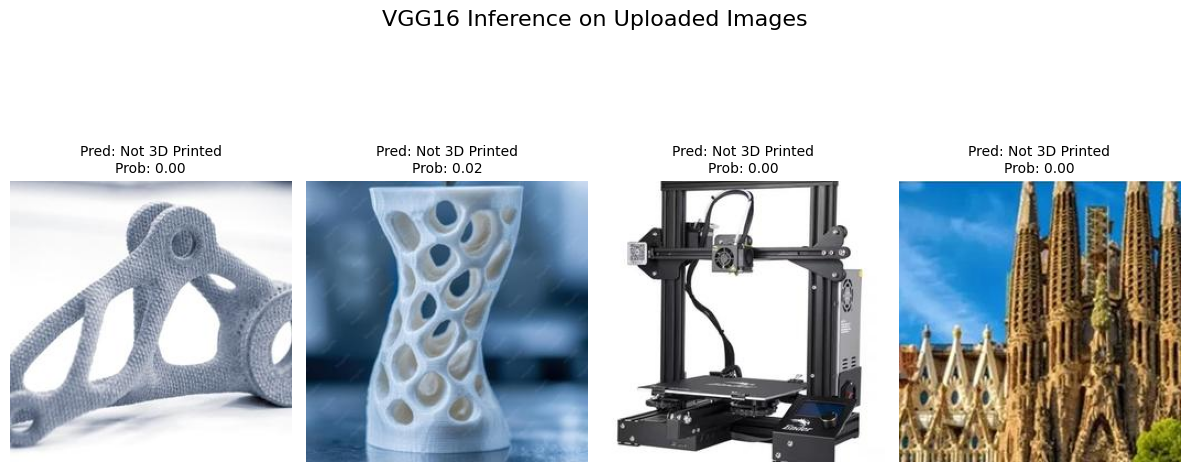

In [12]:
import io
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import preprocess_input
import tensorflow as tf # Required for loading model

# Ensure REAL_CLASS_LABELS and IMG_SIZE are defined, or use defaults/raise error
# These should be defined from cell K-1Le0DsEOG6 if the notebook was run sequentially
if 'REAL_CLASS_LABELS' not in locals():
    print("Warning: REAL_CLASS_LABELS not found. Defining with default values.")
    REAL_CLASS_LABELS = ["Not 3D Printed", "3D Printed"]
if 'IMG_SIZE' not in locals():
    print("Warning: IMG_SIZE not found. Defining with default values.")
    IMG_SIZE = (256, 256)

# Load the VGG16 model if not already loaded
if 'vgg_model' not in locals():
    try:
        vgg_model = tf.keras.models.load_model("final_vgg16_model.keras")
        print("VGG16 model loaded successfully.")
    except Exception as e:
        print(f"Error loading VGG16 model: {e}. Please ensure 'final_vgg16_model.keras' exists and the VGG16 model cell (sAUKNbiCEfGU) has been run.")
        vgg_model = None

if vgg_model is None:
    print("Cannot perform inference as VGG16 model is not available.")
else:
    plt.figure(figsize=(12, 6))
    plt.suptitle("VGG16 Inference on Uploaded Images", fontsize=16)

    display_count = 0
    for fn in uploaded.keys():
        if display_count >= 4: # Limit to 4 images for a neat display
            break

        print(f"\nProcessing {fn}...")
        img_bytes = uploaded[fn]
        img = Image.open(io.BytesIO(img_bytes))

        print(f"Original image size: {img.size}")
        img = img.resize(IMG_SIZE) # Resize to model input size
        print(f"Resized image size: {img.size} (Expected: {IMG_SIZE})")

        img_array = np.array(img)
        if img_array.shape[-1] == 4: # Handle RGBA images by converting to RGB
            img_array = img_array[..., :3]
        if img_array.shape[-1] != 3:
            print(f"Warning: Image {fn} has an unexpected number of channels ({img_array.shape[-1]}). Skipping.")
            continue
        print(f"Image array shape after channel check: {img_array.shape}")

        img_input = preprocess_input(np.expand_dims(img_array, axis=0)) # Add batch dimension and preprocess
        print(f"Input to model (img_input) shape: {img_input.shape}")
        print(f"Input to model (img_input) pixel range: min={img_input.min():.2f}, max={img_input.max():.2f}")

        # Make prediction
        prob = vgg_model.predict(img_input, verbose=0).ravel()[0]
        prediction = int(prob > 0.5)
        predicted_label_name = REAL_CLASS_LABELS[prediction]

        print(f"Raw prediction probability: {prob:.4f}")
        print(f"Predicted label: {predicted_label_name}")

        ax = plt.subplot(1, 4, display_count + 1) # Display up to 4 images in one row
        ax.imshow(img)
        ax.set_title(f"Pred: {predicted_label_name}\nProb: {prob:.2f}", fontsize=10)
        ax.axis('off')
        display_count += 1

    if display_count == 0:
        print("No images were processed for inference.")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()